# 绘图
下面的代码主要是为了绘图，也就是paper里面的一些图都是这里生成的，


## 仿真地点演示图
这里主要是演示仿真中，地面站/用户的分布。
中国：
| 地点           | 纬度 (Latitude)  | 经度 (Longitude)  |
| ------------ | -------------- | --------------- |
| 北京           | **39.9042° N** | **116.4074° E** |
| 重庆           | **29.5630° N** | **106.5516° E** |
| 黑龙江（哈尔滨市，省会） | **45.8038° N** | **126.5350° E** |
| 新疆（乌鲁木齐市，首府） | **43.8256° N** | **87.6168° E**  |
| 海南（海口市，省会）   | **20.0442° N** | **110.1999° E** |



欧洲：
| 国家  | 首都            | 纬度 (Latitude)  | 经度 (Longitude) |
| --- | ------------- | -------------- | -------------- |
| 德国  | 柏林 Berlin     | **52.5200° N** | **13.4050° E** |
| 波兰  | 华沙 Warsaw     | **52.2297° N** | **21.0122° E** |
| 法国  | 巴黎 Paris      | **48.8566° N** | **2.3522° E**  |
| 西班牙 | 马德里 Madrid    | **40.4168° N** | **-3.7038° W** |
| 意大利 | 罗马 Rome       | **41.9028° N** | **12.4964° E** |
| 匈牙利 | 布达佩斯 Budapest | **47.4979° N** | **19.0402° E** |


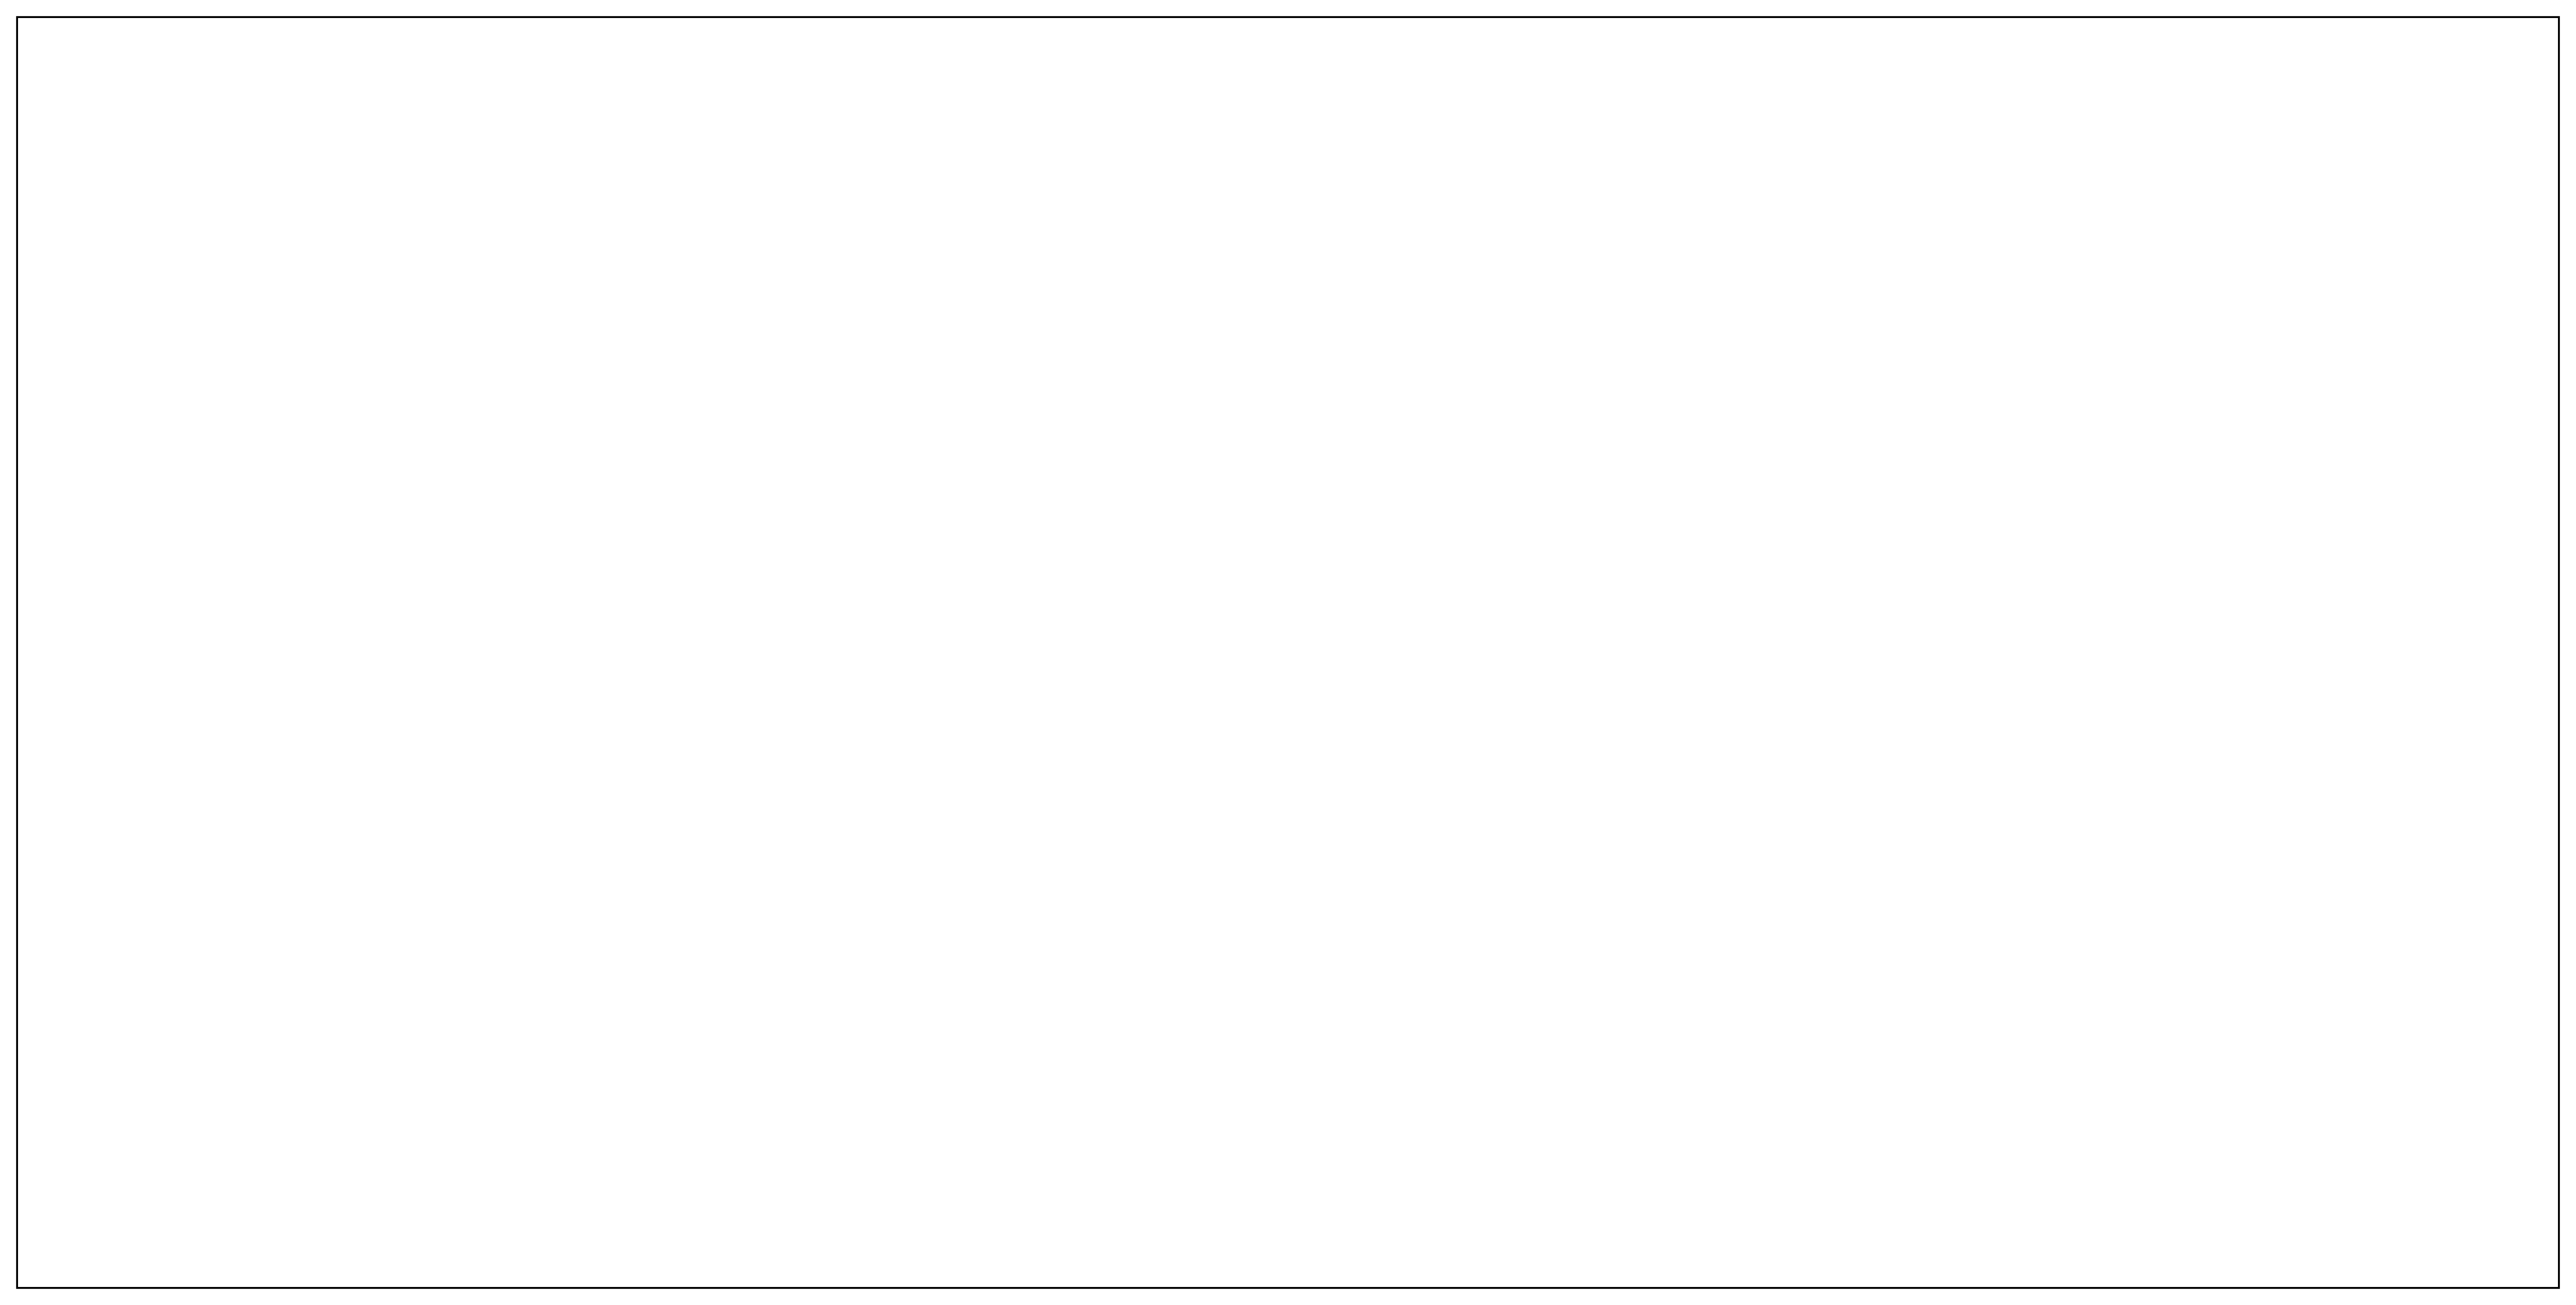

In [3]:
# If needed once: !pip install cartopy matplotlib

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# 3840x2160 像素：选择 19.2x10.8 英寸、dpi=200
fig = plt.figure(figsize=(19.2, 10.8), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())

# ---- Data (lat, lon) ----
china_places = {
    "Beijing":        (39.9042, 116.4074),
    "Chongqing":      (29.5630, 106.5516),

    "Heilongjiang":   (45.8038, 126.5350),   # Harbin
    "Xinjiang":       (43.8256, 87.6168),    # Ürümqi
    "Hainan":         (20.0442, 110.1999),   # Haikou
}

europe_capitals = {
    "Germany":   (52.5200, 13.4050),   # Berlin
    "Poland":    (52.2297, 21.0122),   # Warsaw
    "France":    (48.8566, 2.3522),    # Paris
    "Spain":     (40.4168, -3.7038),   # Madrid
    "Italy":     (41.9028, 12.4964),   # Rome
    "Hungary":   (47.4979, 19.0402),   # Budapest
}

# ---- Plot ----
plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# GLOBAL view
ax.set_global()

# Base map
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

# Optional gridlines
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")

# ±50° latitude reference lines
for lat_line in (-50, 50):
    ax.plot([-180, 180], [lat_line, lat_line], transform=ccrs.Geodetic(),
            linewidth=1.0, color="red")

# China markers (circles)
for (_, (lat, lon)) in china_places.items():
    ax.scatter(lon, lat, s=60, marker="o", color="dodgerblue",
               edgecolor="black", linewidths=0.6,
               transform=ccrs.PlateCarree())

# Europe markers (triangles)
for (_, (lat, lon)) in europe_capitals.items():
    ax.scatter(lon, lat, s=70, marker="^", color="orange",
               edgecolor="black", linewidths=0.6,
               transform=ccrs.PlateCarree())

# Overcast-style global title
plt.title("Global Map: Selected Chinese Cities and European Capitals",
          fontsize=16, color="#4A4A4A", pad=12)

# Simple legend text (no per-point labels)
ax.text(-175, -85, "Circles = China • Triangles = Europe",
        fontsize=10, color="#4A4A4A", transform=ccrs.PlateCarree())

plt.savefig("global_map_4k.png",
            dpi=200,          # 和 fig 里一致即可
            bbox_inches="tight")
plt.close()

#
# plt.show()


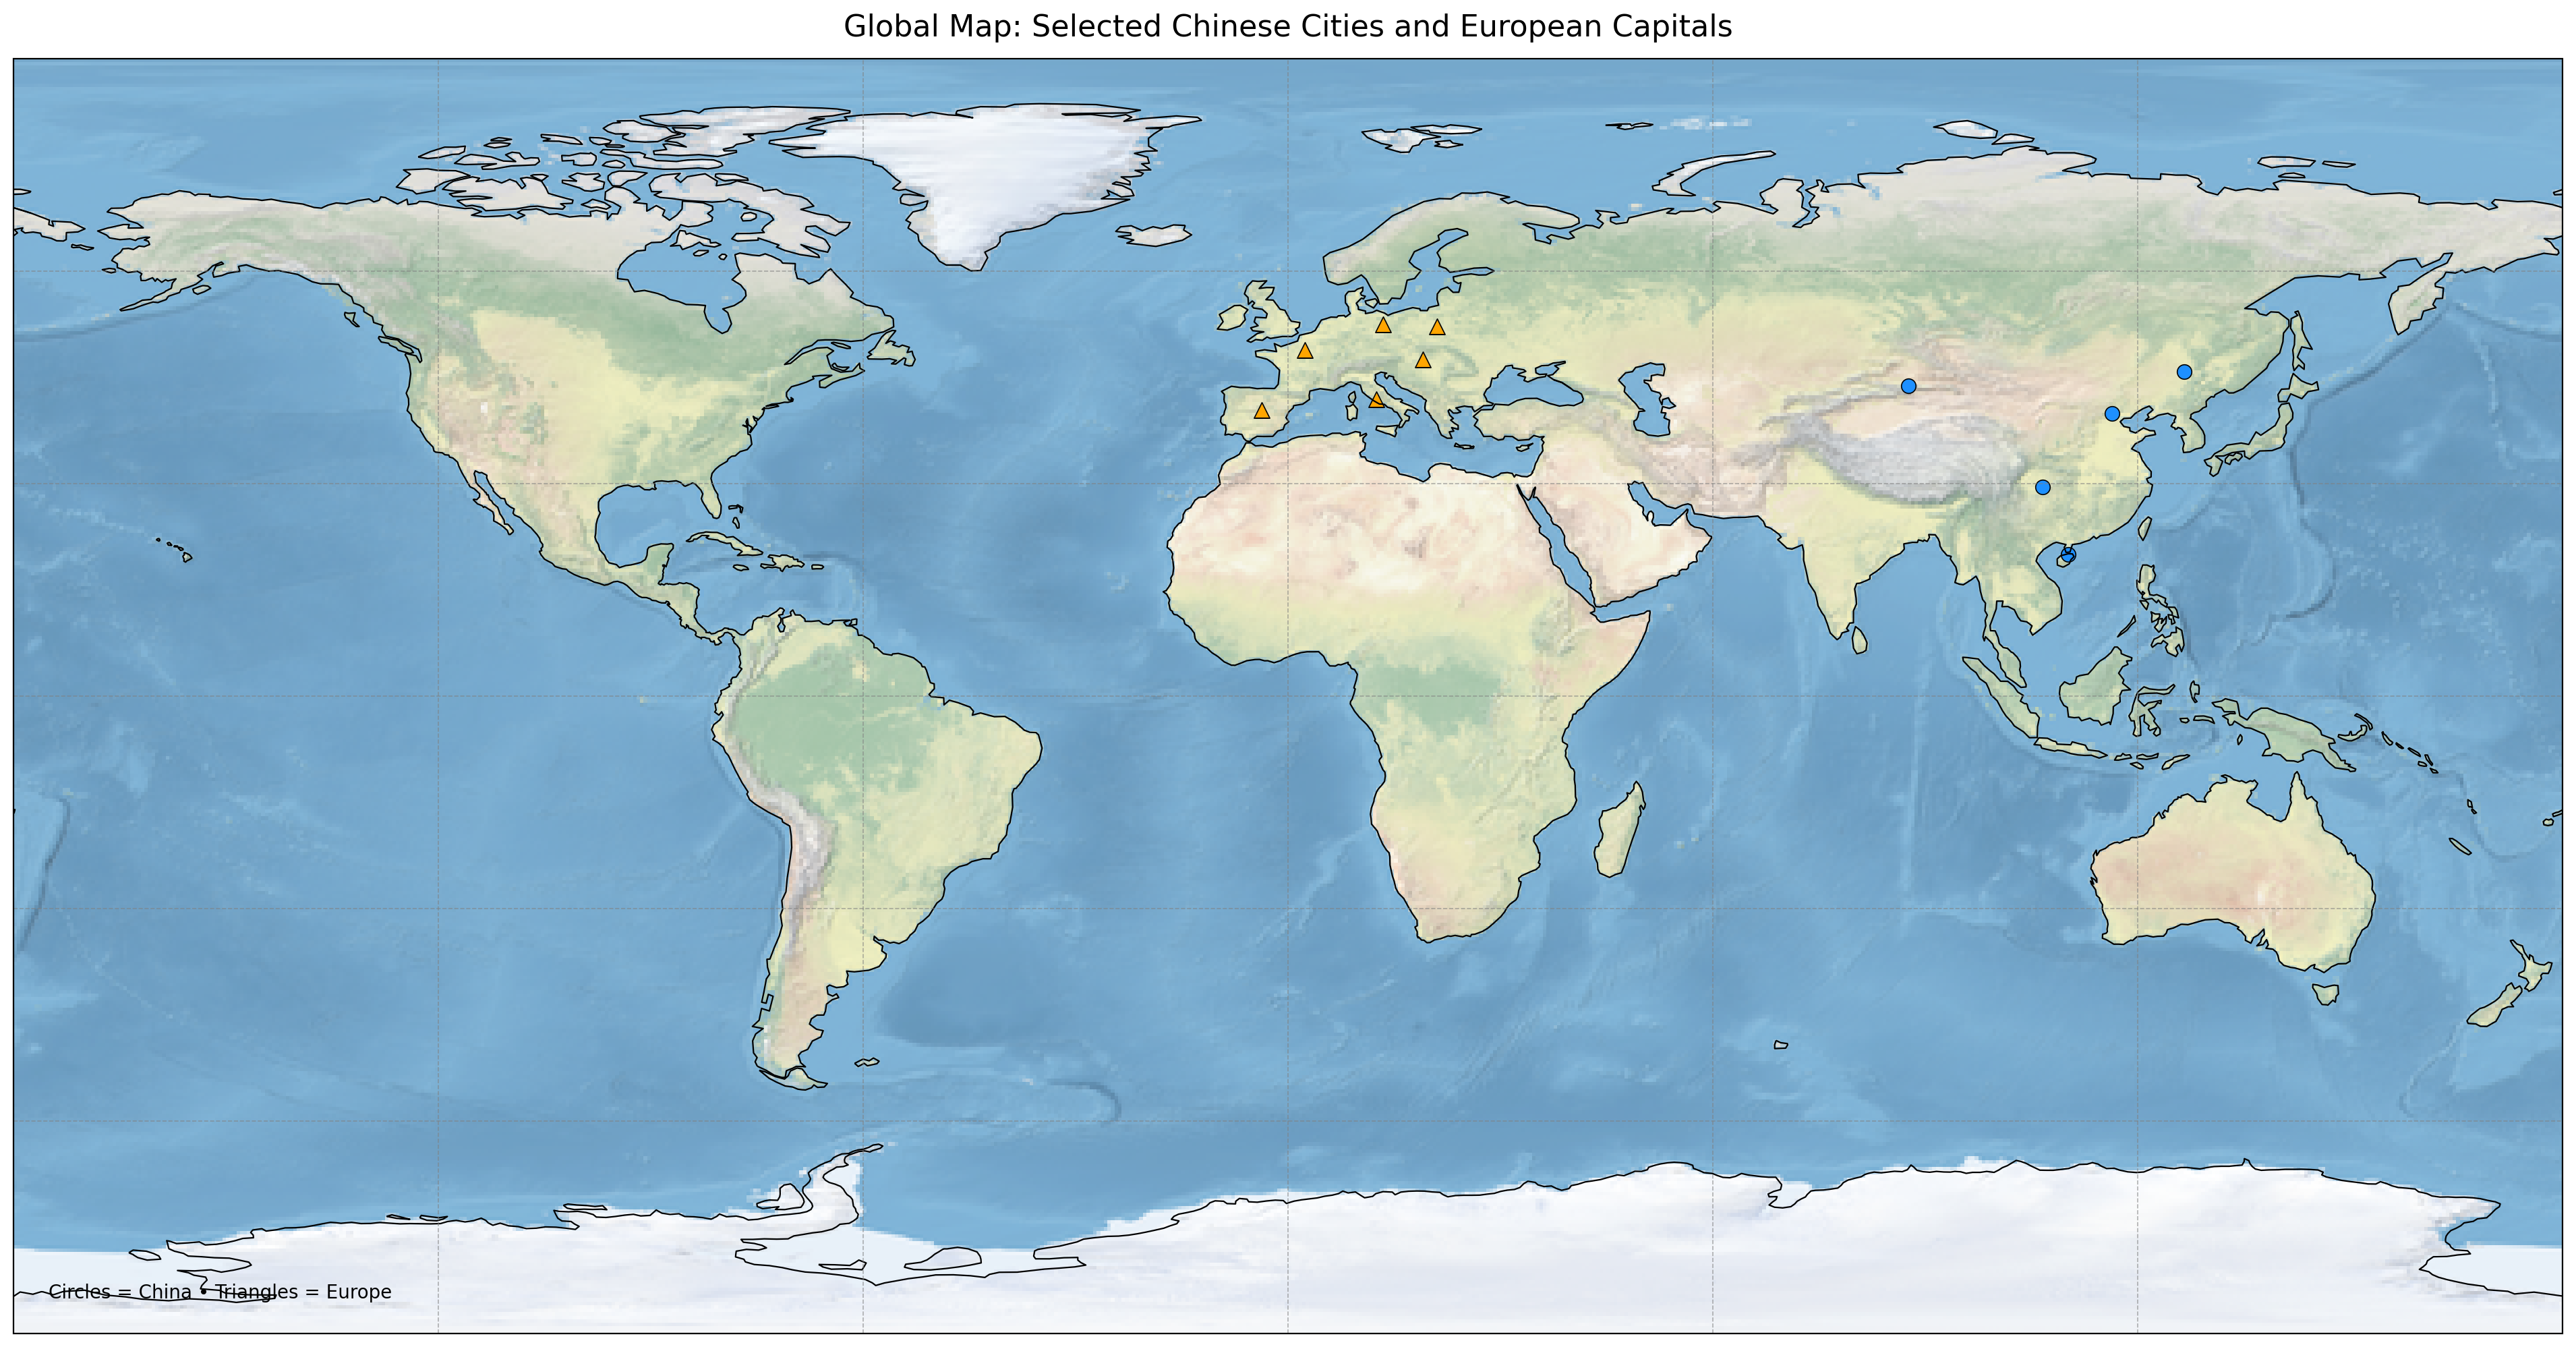

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ---- Data (lat, lon) ----
china_places = {
    "Beijing":        (39.9042, 116.4074),
    "Chongqing":      (29.5630, 106.5516),
    "Heilongjiang":   (45.8038, 126.5350),   # Harbin
    "Xinjiang":       (43.8256, 87.6168),    # Ürümqi
    "Hainan":         (20.0442, 110.1999),   # Haikou
}

europe_capitals = {
    "Germany":   (52.5200, 13.4050),   # Berlin
    "Poland":    (52.2297, 21.0122),   # Warsaw
    "France":    (48.8566, 2.3522),    # Paris
    "Spain":     (40.4168, -3.7038),   # Madrid
    "Italy":     (41.9028, 12.4964),   # Rome
    "Hungary":   (47.4979, 19.0402),   # Budapest
}

# ---- Figure & projection ----
# 4K: 19.2 x 10.8 inch, dpi=200  →  3840 x 2160 像素
fig = plt.figure(figsize=(19.2, 10.8), dpi=200)
proj = ccrs.PlateCarree()
ax = fig.add_subplot(1, 1, 1, projection=proj)

ax.set_global()

# ---- Base map: stock_img 版本 ----
ax.stock_img()
ax.coastlines(resolution="110m", color="black", linewidth=0.8)
ax.gridlines(draw_labels=False, linestyle="--", color="gray",
             linewidth=0.6, alpha=0.6)

# ±50° latitude reference lines
for lat_line in (-50, 50):
    ax.plot(
        [-180, 180], [lat_line, lat_line],
        transform=ccrs.Geodetic(),
        linewidth=1.0, color="red"
    )

# China markers (circles)
for (_, (lat, lon)) in china_places.items():
    ax.scatter(
        lon, lat,
        s=60, marker="o", color="dodgerblue",
        edgecolor="black", linewidths=0.6,
        transform=proj
    )

# Europe markers (triangles)
for (_, (lat, lon)) in europe_capitals.items():
    ax.scatter(
        lon, lat,
        s=70, marker="^", color="orange",
        edgecolor="black", linewidths=0.6,
        transform=proj
    )

# Title & legend
ax.set_title(
    "Global Map: Selected Chinese Cities and European Capitals",
    fontsize=16, pad=12
)
ax.text(
    -175, -85, "Circles = China • Triangles = Europe",
    fontsize=10, transform=proj
)

plt.tight_layout()

# —— 导出 —— #
# 矢量版（论文首选）
fig.savefig("global_map_platecarree.pdf", bbox_inches="tight")

# 光栅 4K 版（3840 x 2160）
fig.savefig("global_map_platecarree_4k.png", dpi=200, bbox_inches="tight")

# 如果想看窗口里的效果，再加这一句
plt.show()

plt.close(fig)


NameError: name 'lons' is not defined

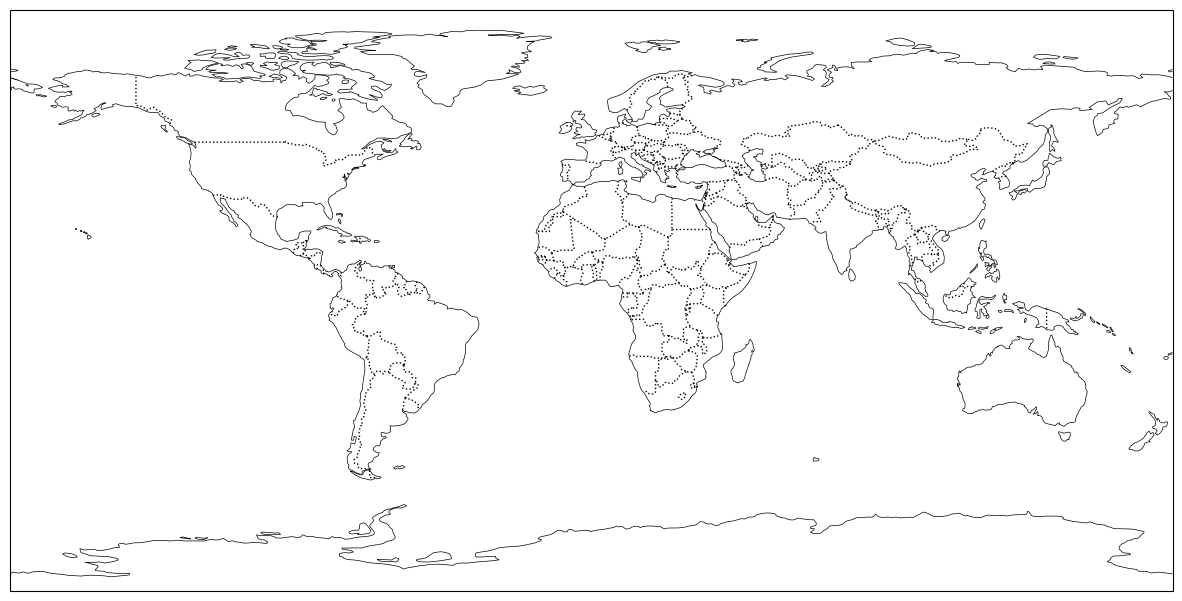

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. 设置画布与投影
fig = plt.figure(figsize=(15, 8))
# PlateCarree 是最常见的等距圆柱投影，类似于 MATLAB 的 eqdcylin
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# 2. 绘制卫星数据
# 假设 lats, lons 是 numpy 数组
plt.scatter(lons, lats, color='blue', s=5, transform=ccrs.PlateCarree(), label='Satellites')

# 3. 绘制星间链路 (ISL) - 关键差异点
# Cartopy 绘制大圆路径需要使用 transform=ccrs.Geodetic()
# 如果直接用 PlateCarree 画线，线是直的；用 Geodetic 画线，线是弯曲的（符合球体几何）
# 论文图中的线如果是弯曲的，说明使用了 Geodetic 变换
for i in range(len(links)):
    start_lon, start_lat = links[i]
    end_lon, end_lat = links[i]
    plt.plot([start_lon, end_lon], [start_lat, end_lat],
             color='gray', linewidth=0.2, transform=ccrs.Geodetic())

# 4. 绘制 DCMR 集群覆盖区
# Cartopy 没有直接的 circle 函数，通常使用 Tissot indicatrix 或手动生成圆点
from cartopy.geodesic import Geodesic
gd = Geodesic()
# 生成以此点为中心，半径为 R 的圆周点
circle_points = gd.circle(lon=src_lon, lat=src_lat, radius=2000000) # 2000km
poly = plt.Polygon(circle_points, facecolor='red', alpha=0.2, transform=ccrs.Geodetic())
ax.add_patch(poly)

# 5. 标注源与目的
plt.scatter([src_lon], [src_lat], marker='*', color='red', s=100, transform=ccrs.PlateCarree(), zorder=10)

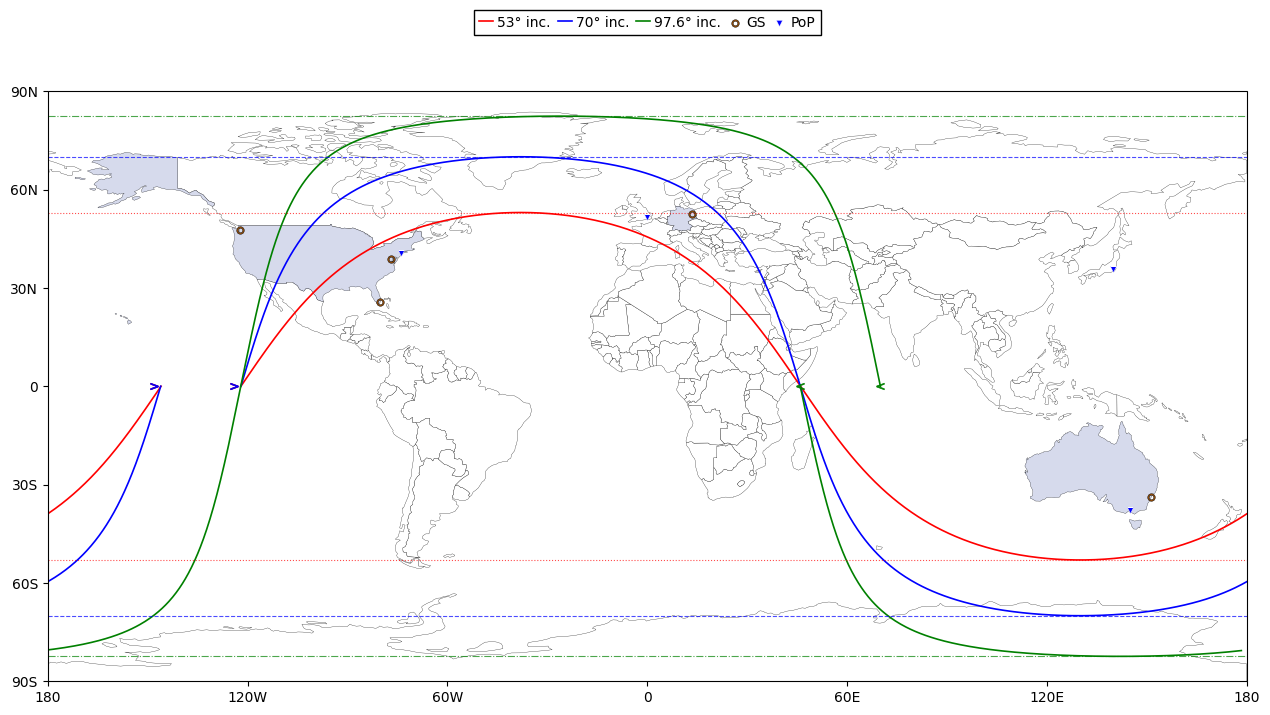

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas
from matplotlib import colors
import cartopy.crs as ccrs
from cartopy.io import shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# ============ 简单的轨道地面迹工具函数（替代 geospatial_plot_utils） ============
R_EARTH = 6378.137
MU = 398600.4418
SIDEREAL_DAY = 86164.0905
OMEGA_E = 2 * np.pi / SIDEREAL_DAY

def get_coords(inc_deg, raan_deg, alt_km, num_points, begin_time, portion=1):
    """
    返回一个轨道周期内的地面迹点列表：[(lat, lon), ...]
    这里简单用圆轨道 + 地球自转，忽略 begin_time 和 portion 的物理精确性，
    只是保证能画出和论文类似的轨道弧线。
    """
    inc = np.radians(inc_deg)
    raan = np.radians(raan_deg)

    a = R_EARTH + alt_km
    T = 2 * np.pi * np.sqrt(a**3 / MU)
    t = np.linspace(0, T, num_points)

    theta = 2 * np.pi * t / T  # 真近点角

    # 纬度
    sin_phi = np.sin(inc) * np.sin(theta)
    sin_phi = np.clip(sin_phi, -1.0, 1.0)
    phi = np.arcsin(sin_phi)
    lat = np.degrees(phi)

    # 赤经 + RAAN
    cos_i = np.cos(inc)
    alpha = np.arctan2(cos_i * np.sin(theta), np.cos(theta))
    alpha_unwrapped = np.unwrap(alpha) + raan

    # 格林尼治恒星时
    gst = OMEGA_E * t
    lam = np.degrees(alpha_unwrapped - gst)

    lon = ((lam + 180) % 360) - 180  # wrap 到 [-180,180]

    return list(zip(lat, lon)), None, None

def plot_period_groundtrack(coords, ax, color, label=None):
    """
    在给定 GeoAxes 上画一条地面迹，coords 为 [(lat, lon), ...]
    自动在经度跳变处断开。
    """
    lats = np.array([c[0] for c in coords])
    lons = np.array([c[1] for c in coords])

    segments = []
    cur_lon, cur_lat = [], []
    for i in range(len(lons)):
        if i > 0 and abs(lons[i] - lons[i-1]) > 180:
            if cur_lon:
                segments.append((np.array(cur_lon), np.array(cur_lat)))
            cur_lon, cur_lat = [], []
        cur_lon.append(lons[i])
        cur_lat.append(lats[i])
    if cur_lon:
        segments.append((np.array(cur_lon), np.array(cur_lat)))

    for lon_seg, lat_seg in segments:
        ax.plot(lon_seg, lat_seg,
                color=color, linewidth=1.2,
                transform=ccrs.PlateCarree(),
                label=label)
        # 只第一个 segment 用 label
        label = None

# ====================== 原始绘图逻辑（去掉外部数据） ============================
continents = ["AF", "AS", "EU", "NA", "OC", "SA"]
cols = ["#c1d5e2", "#ce9c7f", "#7598b6", "#6a7465", "#914c09", "#663979", "#fbe17b"]

# 使用 Cartopy 自带的 Natural Earth 数据
shpfilename = shpreader.natural_earth(
    resolution='110m', category='cultural', name='admin_0_countries'
)
world = geopandas.read_file(shpfilename)

# 自动选择国家名列
if "name" in world.columns:
    NAME_COL = "name"
elif "NAME" in world.columns:
    NAME_COL = "NAME"
elif "NAME_LONG" in world.columns:
    NAME_COL = "NAME_LONG"
else:
    print("Warning: 未找到国家名列，不高亮国家。")
    NAME_COL = None

fig, ax = plt.subplots(figsize=(12.8, 7.2), subplot_kw={'projection': ccrs.PlateCarree()})

cmap = colors.ListedColormap(cols[:-2])
world.plot(facecolor="white", edgecolor="black", ax=ax, linewidth=0.2)

# 高亮几个示例国家（代替外部 countries）
countries = ["United States of America", "Germany", "Australia"]

def plotCountryPatch(axes, country_name, fcolor):
    if NAME_COL is None:
        return
    nami = world[world[NAME_COL] == country_name]
    if nami.empty:
        return
    geom = nami.geometry
    axes.add_geometries(
        geom,
        crs=ccrs.PlateCarree(),
        facecolor=fcolor,
        edgecolor="none",
        alpha=0.2,
        zorder=2,
    )

for c in countries:
    plotCountryPatch(ax, c, "#364aa0")

begin_time = 1679408909

# 53° 轨道
coords, bc1, bc2 = get_coords(53, 238, 550, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "red", label="53° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] - 2 for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$>$', zorder=10, color="red", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 70° 轨道
coords, bc1, bc2 = get_coords(70, 238, 570, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "blue", label="70° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] - 2 for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$>$', zorder=10, color="blue", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 97.6° 轨道
coords, bc1, bc2 = get_coords(97.6, 70, 560, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "green", label="97.6° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$<$', zorder=10, color="green", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 纬度覆盖线
def plot_extent(inclination, color="r", lw=1.4, alpha=0.7, lt="dotted"):
    if inclination > 90:
        inclination = 90 - (inclination % 90)
    ax.plot(
        [-180, 180], [inclination, inclination],
        linewidth=lw, color=color, linestyle=lt, alpha=alpha,
        transform=ccrs.PlateCarree()
    )
    ax.plot(
        [-180, 180], [-inclination, -inclination],
        linewidth=lw, color=color, linestyle=lt, alpha=alpha,
        transform=ccrs.PlateCarree()
    )

plot_extent(53, "r", lt="dotted", lw=0.8)
plot_extent(70, "b", lt="dashed", lw=0.8)
plot_extent(97.6, "g", lt="dashdot", lw=0.8)

# 简单构造几个 GS / PoP 点（替代 gateway_df / pop_df）
gateway_df = pd.DataFrame({
    "lat": [47.6, 25.8, -33.9, 38.9, 52.5],
    "long": [-122.3, -80.2, 151.2, -77.0, 13.4],
})
pop_df = pd.DataFrame({
    "lat": [40.7, 51.5, 35.7, -37.8],
    "long": [-74.0, -0.12, 139.8, 145.0],
})

def plot_gsdata(gsdata_df, ax, label, marker, color, size=10, lw=0.6):
    latitude, longitude = gsdata_df["lat"], gsdata_df["long"]
    ax.scatter(
        longitude, latitude,
        s=size,
        color=color,
        zorder=10,
        marker=marker,
        linewidths=lw,
        edgecolors="black" if marker == "$\\circ$" else "white",
        transform=ccrs.PlateCarree(),
        label=label,
    )

ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())


# ax.get_xaxis().set_ticks([])
# ax.get_yaxis().set_ticks([])
# ==== 增加经纬度刻度 ====
xticks = np.arange(-180, 181, 60)   # 经度刻度：-180, -120, ..., 180
yticks = np.arange(-90, 91, 30)     # 纬度刻度：-90, -60, ..., 90
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(number_format='.0f', degree_symbol='')
lat_formatter = LatitudeFormatter(number_format='.0f', degree_symbol='')
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

plot_gsdata(gateway_df, ax, "GS", "$\\circ$", cols[4], 30, lw=0.3)
plot_gsdata(pop_df, ax, "PoP", "v", "blue", 20, lw=0.3)

ax.legend(
    loc='upper center', bbox_to_anchor=(0.50, 1.15),
    ncol=5, edgecolor="k", handlelength=1, labelspacing=0.06,
    columnspacing=0.5, fancybox=False, shadow=False,
    handletextpad=0.3, framealpha=1.0
).set_zorder(100)

plt.axis('tight')
plt.tight_layout()

result_path = "."  # 当前目录
plt.savefig(f"{result_path}/fig01_inclination_starlink_comparison_with_gws.pdf",dpi=300,
            bbox_inches="tight", pad_inches=0)


plt.savefig(f"{result_path}/fig01_inclination_starlink_comparison_with_gws.svg",
            bbox_inches="tight", pad_inches=0)
plt.show()


参考的效果为下图
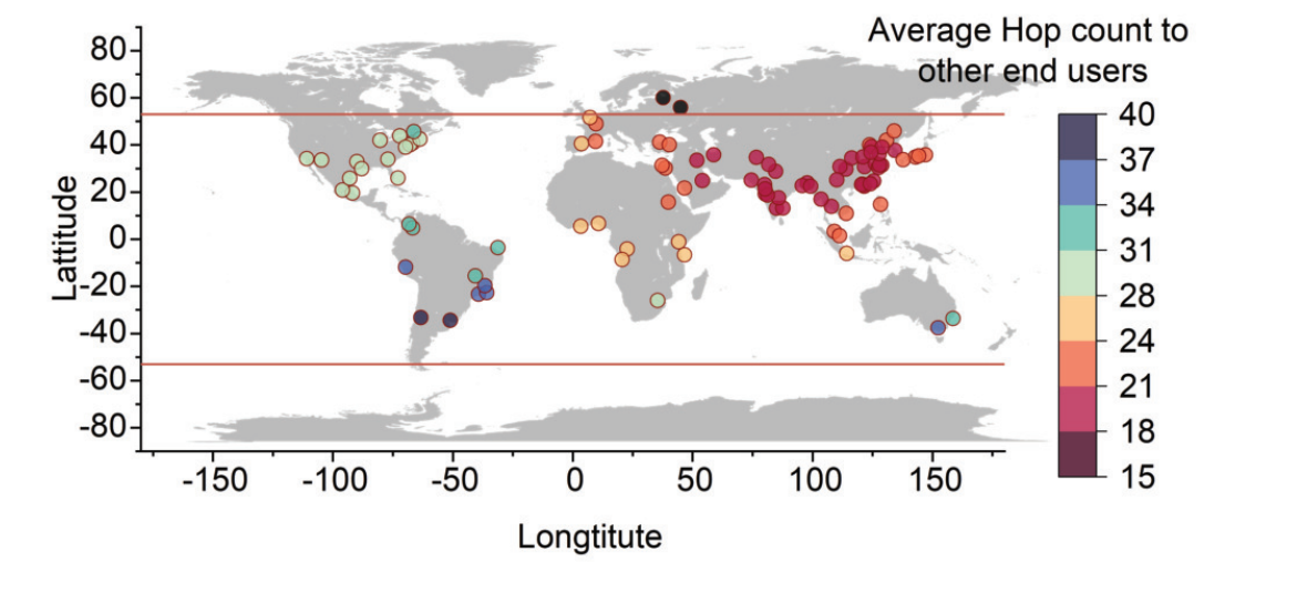

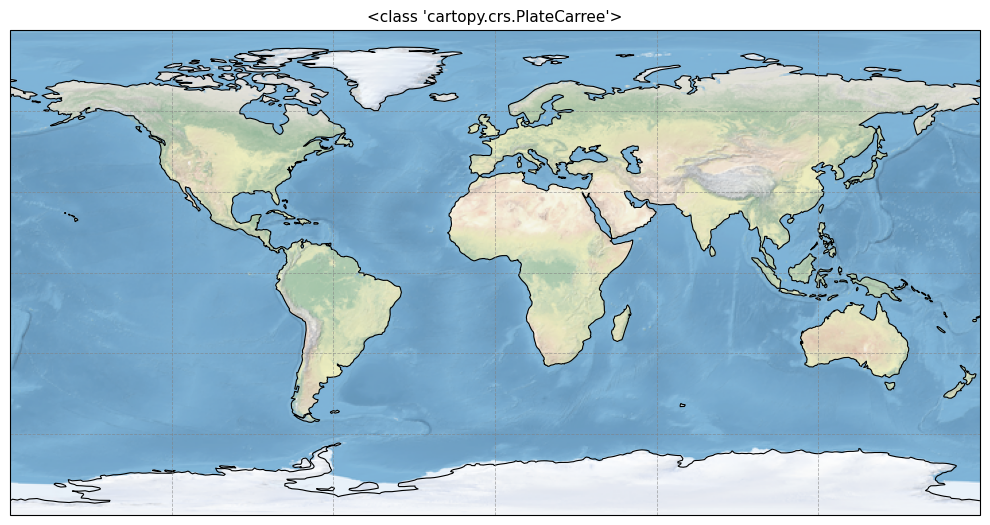

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(10, 6))
proj = ccrs.PlateCarree()

ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_global()
ax.stock_img()
ax.coastlines(resolution="110m", color="black", linewidth=0.8)
ax.gridlines(draw_labels=False, linestyle="--", color="gray", linewidth=0.6, alpha=0.6)
ax.set_title(str(type(proj)), fontsize=11)

plt.tight_layout()
# —— 导出 —— #
fig.savefig("world_platecarree.pdf", bbox_inches="tight")                 # 矢量，论文首选
fig.savefig("world_platecarree.png", dpi=300, bbox_inches="tight")        # 光栅，300dpi
# fig.savefig("world_platecarree.png", dpi=600, bbox_inches="tight", transparent=True)  # 透明背景可选

plt.show()

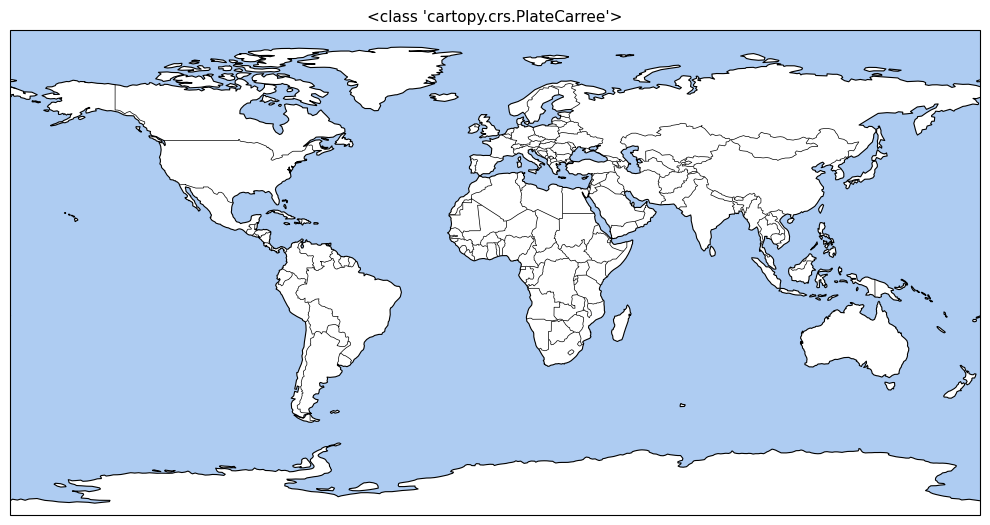

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 6))
proj = ccrs.PlateCarree()

ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_global()

# —— 你的配色 —— #
ocean_fc = "#AECCF2"  # RGB(174, 204, 242)
land_fc  = "#FFFFFF"

# 海陆填色（替代 stock_img）
ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor=ocean_fc, edgecolor="none")
ax.add_feature(cfeature.LAND.with_scale("110m"),  facecolor=land_fc,  edgecolor="none")
# 可选：湖泊也用同色海洋（更统一）
# ax.add_feature(cfeature.LAKES.with_scale("110m"), facecolor=ocean_fc, edgecolor="none")

# 海岸线
ax.coastlines(resolution="110m", color="black", linewidth=0.8)
# 国家边界线（关键新增）
ax.add_feature(cfeature.BORDERS.with_scale("110m"), edgecolor="black", linewidth=0.5)


ax.set_title(str(type(proj)), fontsize=11)



plt.tight_layout()

# —— 导出 —— #
fig.savefig("world_platecarree.pdf", bbox_inches="tight")          # 矢量
fig.savefig("world_platecarree.png", dpi=300, bbox_inches="tight") # 300dpi 光栅
# fig.savefig("world_platecarree.png", dpi=600, bbox_inches="tight", transparent=True)

plt.show()


In [32]:
import sympy as sp

a = sp.Symbol('a', real=True)

R1 = sp.Matrix([
    [sp.cos(a), 0, -sp.sin(a)],
    [0,         1,  0        ],
    [sp.sin(a), 0,  sp.cos(a)]
])


b = sp.Symbol('b', real=True)

R2 = sp.Matrix([
    [sp.cos(b), sp.sin(b), 0],
    [-sp.sin(b),         sp.cos(b),  0        ],
    [0, 0,  1]
])

c = sp.Symbol('c', real=True)

R3 = sp.Matrix([
    [1,0,0],
    [0,sp.cos(c),-sp.sin(c)       ],
    [0, sp.sin(c),sp.cos(c)]
])



In [33]:
R1_inv = R1.inv()   # 符号逆
R2_inv = R2.inv()   # 符号逆
R3_inv = R3.inv()   # 符号逆

In [34]:
R = R3_inv@R2_inv@R1_inv

In [35]:
a1 = sp.Matrix([1, 0, 0])   # 3x1 列向量

In [36]:
a1_ = R @a1
a1_

Matrix([
[                       (-sin(a)**2/cos(a) + 1/cos(a))*(-sin(b)**2/cos(b) + 1/cos(b))],
[(-sin(a)**2/cos(a) + 1/cos(a))*(-sin(c)**2/cos(c) + 1/cos(c))*sin(b) - sin(a)*sin(c)],
[                       -(-sin(a)**2/cos(a) + 1/cos(a))*sin(b)*sin(c) - sin(a)*cos(c)]])

In [30]:




a1__pretty = a1_.applyfunc(lambda x: sp.expand(sp.trigsimp(x)))
a1__pretty


Matrix([
[cos(a)*cos(b)],
[sin(b)*cos(a)],
[      -sin(a)]])

Matrix([
[sqrt(2)*sin(a + pi/4)*cos(b)],
[sqrt(2)*sin(b)*sin(a + pi/4)],
[       sqrt(2)*cos(a + pi/4)]])

In [5]:
a=0
for i in range(360):
    a= a*1.015+2000

In [6]:
a

28227170.785575442

上面的图是参考
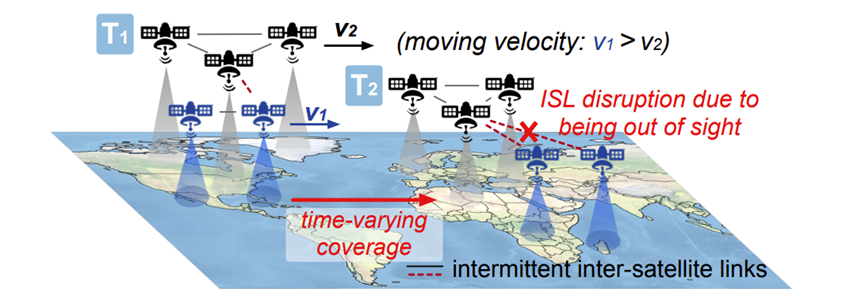